<a href="https://colab.research.google.com/github/SAVCHink2042/ML-algorithm/blob/main/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%D0%BD%D0%BE%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**𝟙**. **Описание набора данных, Постановка задачи, Описание выбранного классификатора**


Набор данных представляет собой таблицу, в которой указаны 5 признаковых переменных и 1 целевая ( категориальная). В качестве признаков выступают следующие показатели:

1. STG (Study Time for Goal objects) — время изучения целевых материалов.
2. SCG (Study Cycle for Goal objects) — количество повторений / циклов изучения целевых материалов.
3. STR (Study Time for Related objects) — время изучения связанных с целевыми материалов.
4. LPR (Learning Performance for Related objects) — экзаменационная успеваемость по связанным материалам.
5. PEG (Performance Exam for Goal objects) — экзаменационная успеваемость по целевым материалам.

и целевая:

UNS (The knowledge level of user) - уровень знаний пользователя.


Задача: построить модель, которая на основе входных данных - информации об успеваимости и временных затратах ученика на подготовку к экзамену - будет оценивать уровень знаний. Поставленная задача относится к классифиционному типу.

В качестве модели выбран метод LDA - Линейный дискриминантый анализ.
Т.е. будет построена фнукция вида
 $$ D = b_0 + b_1 X_1 + b_2 X_2 + ... + b_n X_n $$




**𝟚. Подключение библиотек и Чтение данных**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, accuracy_score, precision_score, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

url = "https://raw.githubusercontent.com/yakushinav/journ_prg/main/Data_User_Modeling_Dataset.csv"

data = pd.read_csv( url )

print( "количество столбцов ", data.shape[0] )
print( "количество строк ", data.shape[1] )
print( data.head() )

количество столбцов  403
количество строк  6
    STG   SCG   STR   LPR   PEG       UNS
0  0.00  0.00  0.00  0.00  0.00  very_low
1  0.08  0.08  0.10  0.24  0.90      High
2  0.06  0.06  0.05  0.25  0.33       Low
3  0.10  0.10  0.15  0.65  0.30    Middle
4  0.08  0.08  0.08  0.98  0.24       Low


𝟛. Характеристики набора данных и визуализация

Посмотрим на возможные значения целевой.

In [ ]:
print( data['UNS'].unique()  )


['very_low' 'High' 'Low' 'Middle']


Все признаки можем считать независимыми на основе значений корреляционной матрицы

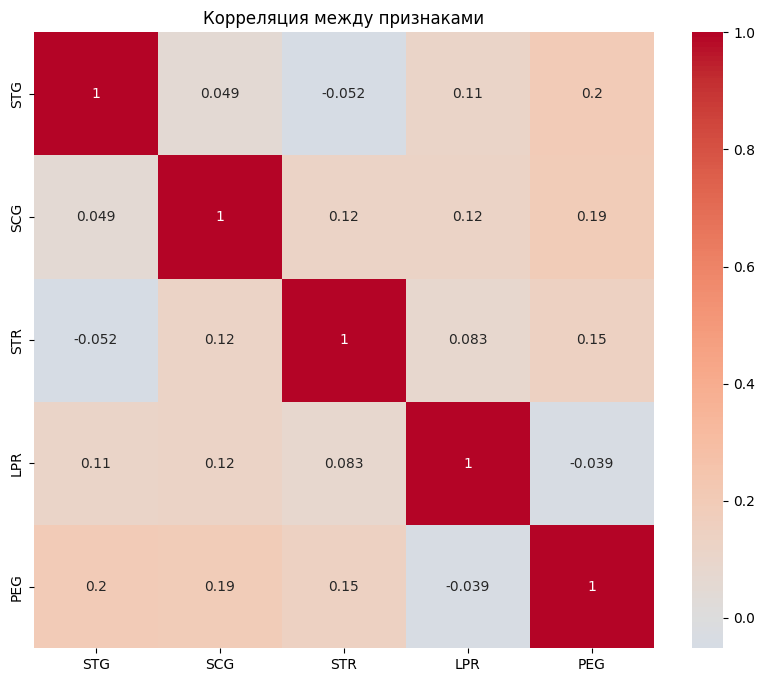

In [ ]:
plt.figure( figsize=(10, 8) )
sns.heatmap( data[['STG', 'SCG', 'STR', 'LPR', 'PEG']].corr(), annot=True, cmap='coolwarm', center=0 )
plt.title('Корреляция между признаками')
plt.show()

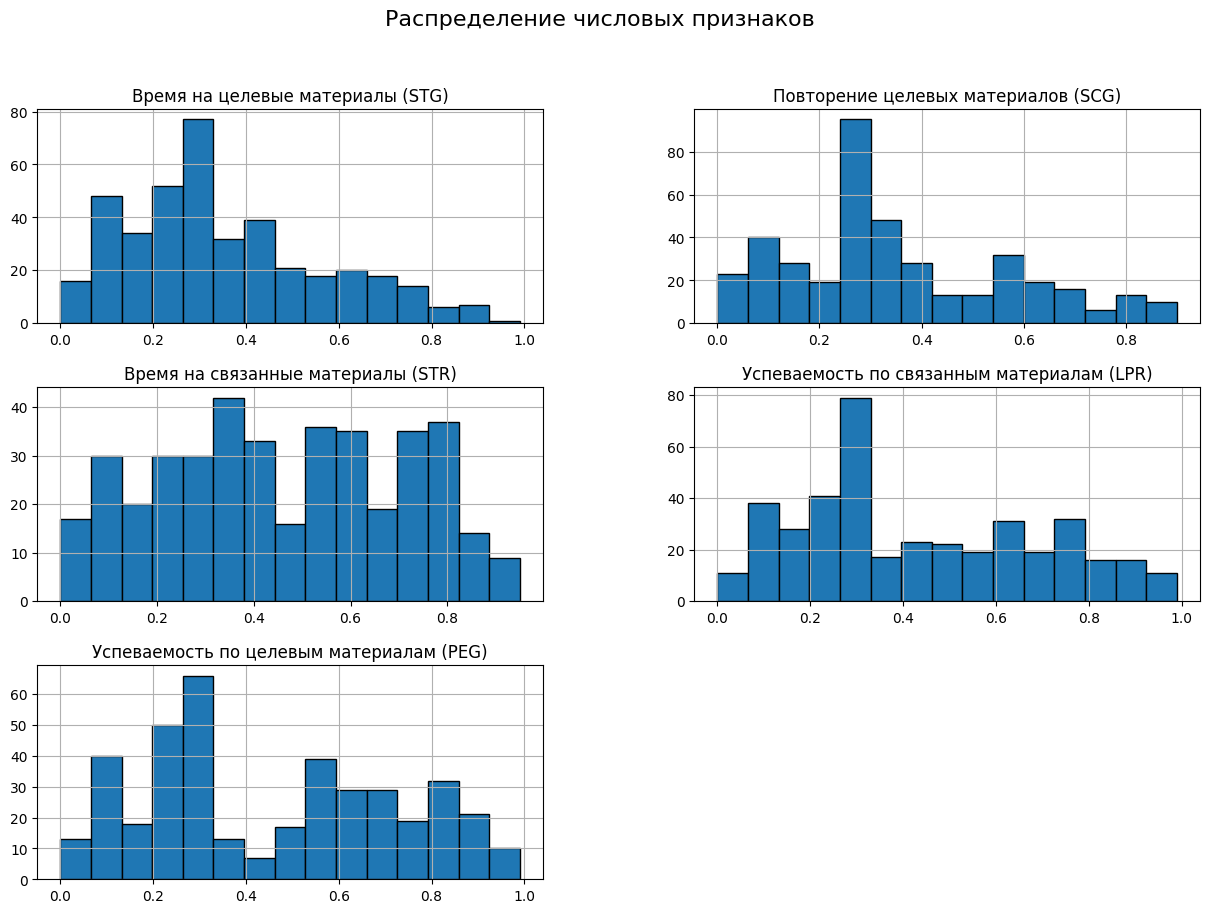

In [ ]:
data_plot = data.rename(columns={
    'STG': 'Время на целевые материалы (STG)',
    'SCG': 'Повторение целевых материалов (SCG)',
    'STR': 'Время на связанные материалы (STR)',
    'LPR': 'Успеваемость по связанным материалам (LPR)',
    'PEG': 'Успеваемость по целевым материалам (PEG)'
})

data_plot[['Время на целевые материалы (STG)',
           'Повторение целевых материалов (SCG)',
           'Время на связанные материалы (STR)',
           'Успеваемость по связанным материалам (LPR)',
           'Успеваемость по целевым материалам (PEG)']].hist(figsize=(15, 10), bins=15, edgecolor='black')

plt.suptitle('Распределение числовых признаков', fontsize=16)
plt.show()

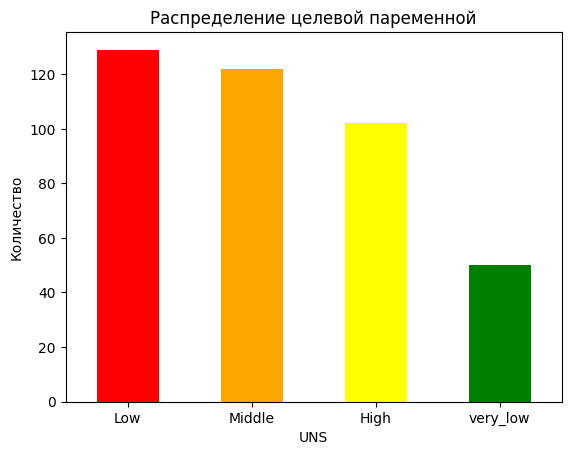

In [ ]:
data['UNS'].value_counts().plot(kind='bar', color=['red', 'orange', 'yellow', 'green'])
plt.title('Распределение целевой паременной')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_896/1664515970.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(box_data, labels=labels, patch_artist=True)


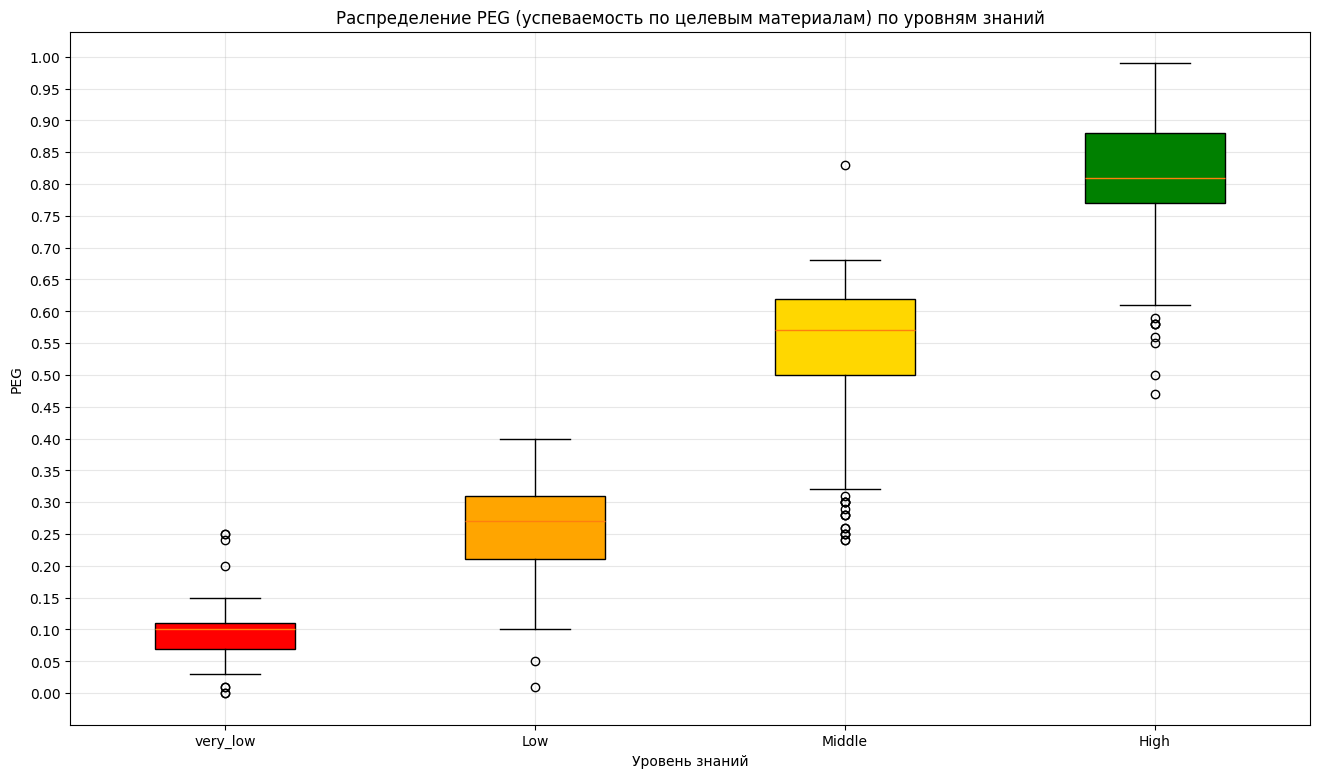

In [ ]:
plt.figure(figsize=(16, 9))

box_data = []
labels = []
for level in ['very_low', 'Low', 'Middle', 'High']:
    values = data[data['UNS'] == level]['PEG'].dropna()
    box_data.append(values)
    labels.append(level)

box = plt.boxplot(box_data, labels=labels, patch_artist=True)

for patch, (level, color) in zip(box['boxes'], colors.items()):
    patch.set_facecolor(color)

ax = plt.gca()
ax.set_yticks(np.arange(0, 1.05, 0.05))
ax.grid(True, alpha=0.3)

plt.title('Распределение PEG (успеваемость по целевым материалам) по уровням знаний')
plt.xlabel('Уровень знаний')
plt.ylabel('PEG')
plt.show()

𝟝. Построение модели машинного обучения

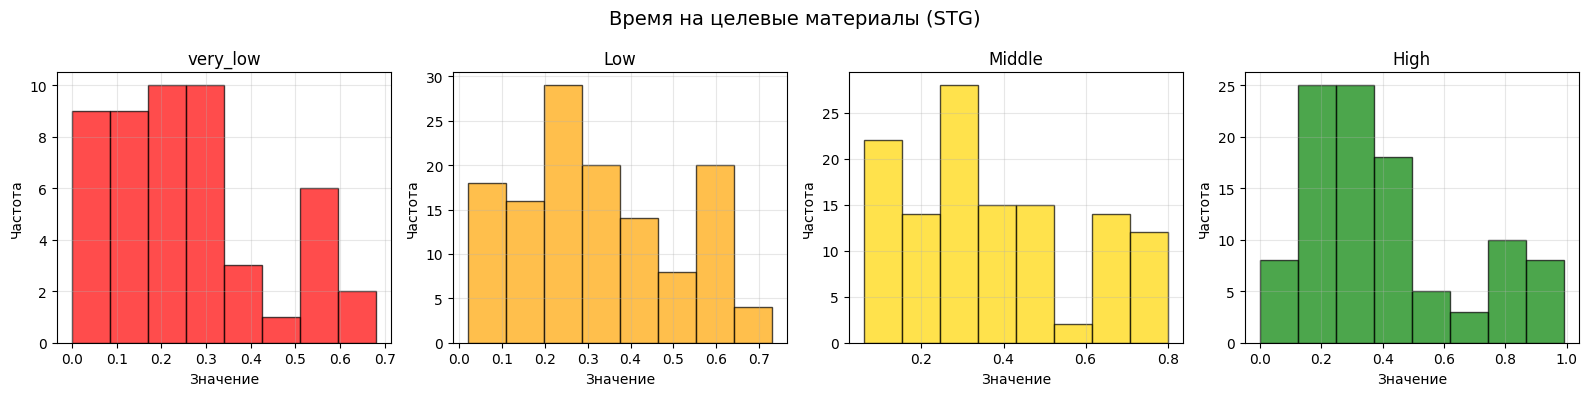

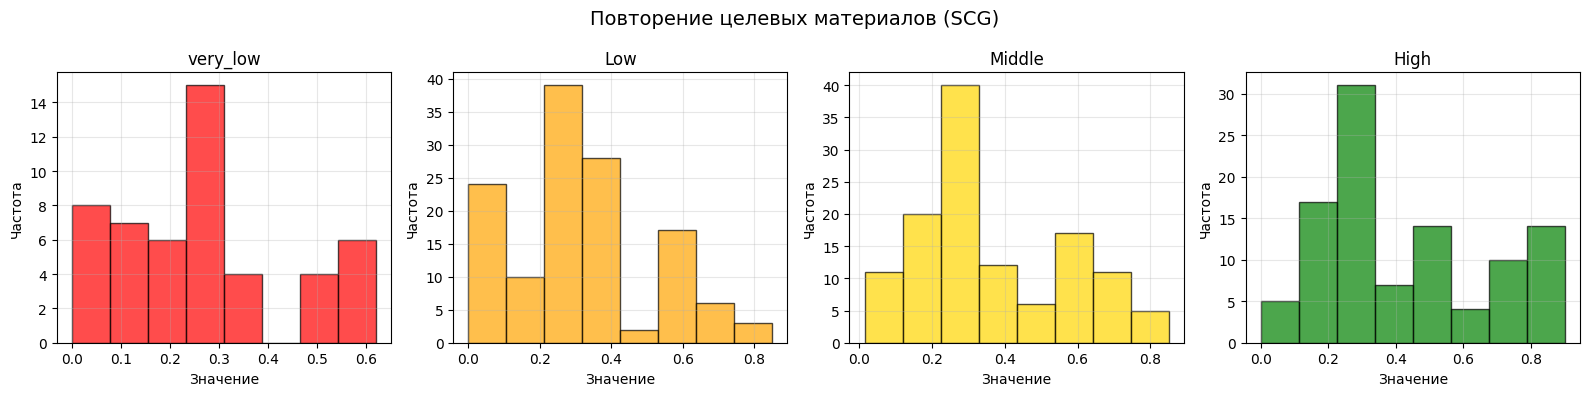

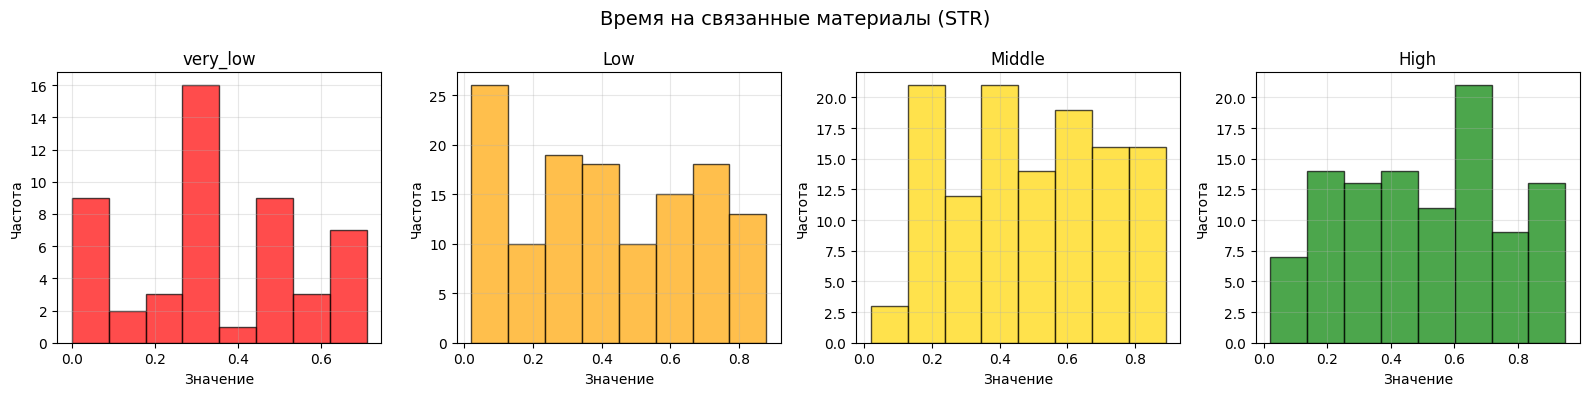

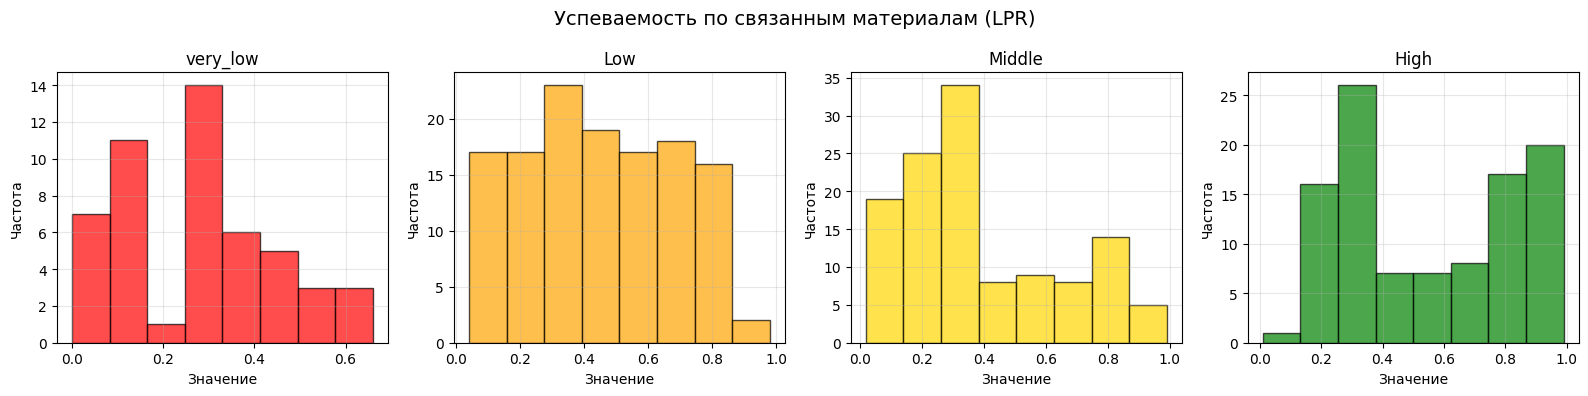

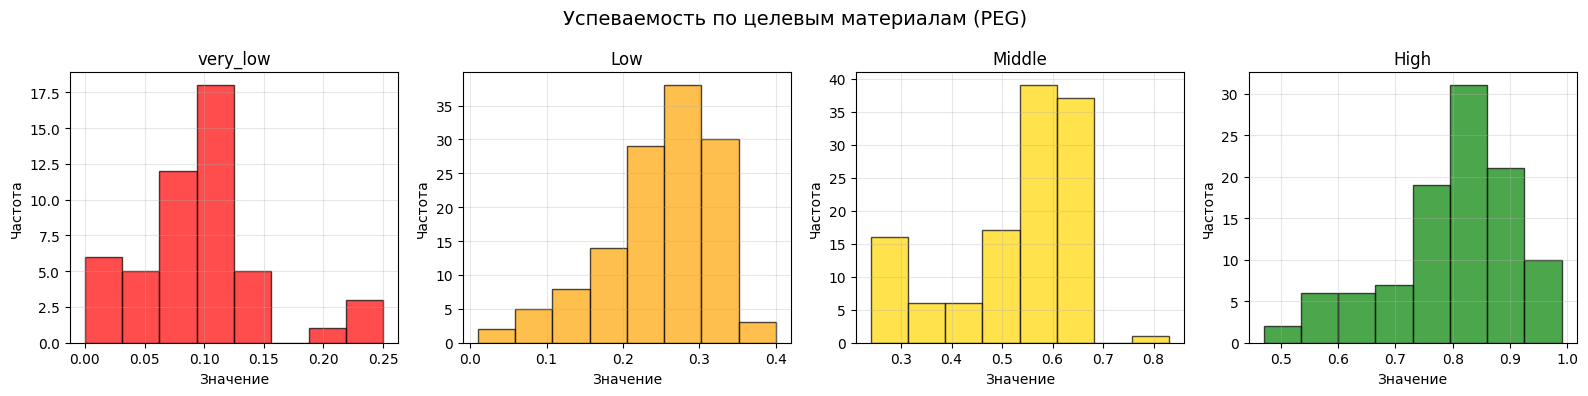

In [ ]:
colors = {'very_low': 'red', 'Low': 'orange', 'Middle': 'gold', 'High': 'green'}
classes = ['very_low', 'Low', 'Middle', 'High']
features = ['STG', 'SCG', 'STR', 'LPR', 'PEG']

rus_names = {
    'STG': 'Время на целевые материалы (STG)',
    'SCG': 'Повторение целевых материалов (SCG)',
    'STR': 'Время на связанные материалы (STR)',
    'LPR': 'Успеваемость по связанным материалам (LPR)',
    'PEG': 'Успеваемость по целевым материалам (PEG)'
}

for feature in features:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for i, level in enumerate(classes):
        subset = data[data['UNS'] == level][feature]
        axes[i].hist(subset, bins=8, alpha=0.7, color=colors[level], edgecolor='black')
        axes[i].set_title(f'{level}', fontsize=12)
        axes[i].set_xlabel('Значение')
        axes[i].set_ylabel('Частота')
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(rus_names[feature], fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
X = data.drop( 'UNS', axis = 1 )
Y = data[ 'UNS']

class_mapping = {
    'very_low': 0,
    'Low': 1,
    'Middle': 2,
    'High': 3
}
Y = data['UNS'].map(class_mapping)

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size = 0.2)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, Y_train)

predict = lda.predict(X_val)
print(predict)


[1 2 0 2 1 2 0 2 2 1 0 3 1 2 1 2 3 3 0 1 1 3 3 2 1 2 2 3 1 1 2 0 2 1 0 2 1
 1 3 2 1 1 3 0 2 1 1 1 2 1 1 3 1 1 1 1 2 1 1 3 0 3 1 1 1 3 3 1 3 0 3 1 3 2
 3 3 3 1 2 1 2]


𝟞. расчет метрик построенной модели.

ТP - true positive   -  Объекты, правильно отнесённые моделью к положительному классу

TN - true negative  -  Объекты, правильно отнесённые моделью к отрицательному классу

FP - false positive  -  Объекты, ошибочно отнесённые моделью к положительному классу

FN - false naegetive  -  Объекты, ошибочно отнесённые моделью к отрицательному классу


recall = $TP/(TP + FN)$

precision = $TP/(TP + FP )$

В нашем случае многоклассовая классификации. Необходимо адаптировать метрики выше.

 Пусть $recall_i, precision_i$ - значение recall и precision соответственно для случая, когда класс i - считается истинным (то есть 1), остальные ложными (0).

Макро усреднение:

$ recall = ( recall_1 + recall_2 + recall_3 + recall_4 ) / 4 $

$precision = ( precision_1 + precision_2 + precision_3 + precision_4 ) / 4 $

Микро усреднение:

recall    = $ ( ΣTP_i ) / (ΣTP_i + ΣFN_i) $

precision = $ ( ΣTP_i ) / (ΣTP_i + ΣFP_i)  $

Весовое усрденение:

recall    = $ w₁·recall₁ + w₂·recall₂ + w₃·recall₃ + w₄·recall₄ $

precision = $ w₁·precision₁ + w₂·precision₂ + w₃·precision₃ + w₄·precision₄ $

Где $w_i$ - доля элементов класса i из валидационной выборки.

In [ ]:
print("Доля верных классификаций - Accuracy ", accuracy_score(Y_val, predict), '\n' )

print("Макро усреднение метрик recall, precision")
print("Recall     ", recall_score(Y_val, predict, average = 'macro') )
print("Precision  ", precision_score(Y_val, predict, average = 'macro') )

print('\n', "Микро усреднение метрик recall, precision")
print("Recall     ",  recall_score(Y_val, predict, average = 'micro') )
print("Precision  ",  precision_score(Y_val, predict, average = 'micro') )

print('\n',"Усреднение с весами равными доле каждого класса")
print("Recall     ",  recall_score(Y_val, predict, average = 'weighted') )
print("Precision  ",  precision_score(Y_val, predict, average = 'weighted') )



Доля верных классификаций - Accuracy  0.9506172839506173 

Макро усреднение метрик recall, precision
Recall      0.9255952380952381
Precision   0.9696969696969697

 Микро усреднение метрик recall, precision
Recall      0.9506172839506173
Precision   0.9506172839506173

 Усреднение с весами равными доле каждого класса
Recall      0.9506172839506173
Precision   0.9566030677141788


 ROC-кривая и AUC для многоклассовой классификации

TPR (True Positive Rate) — доля верно классифицированных положительных объектов

FPR (False Positive Rate) — доля ошибочно классифицированных отрицательных объектов

TPR = TP / (TP + FN)

FPR = FP / (FP + TN)

ROC-кривая — график зависимости TPR от FPR при изменении порога классификации - вероятности в нашем случае .

AUC (Area Under Curve) — площадь под ROC-кривой.

 Для каждого класса i строится своя ROC-кривая, где:
 класс i считается положительным (1), все остальные объединяются в отрицательный класс (0)

В результате получаем 4 ROC-кривых на одном графике — по одной для каждого класса.



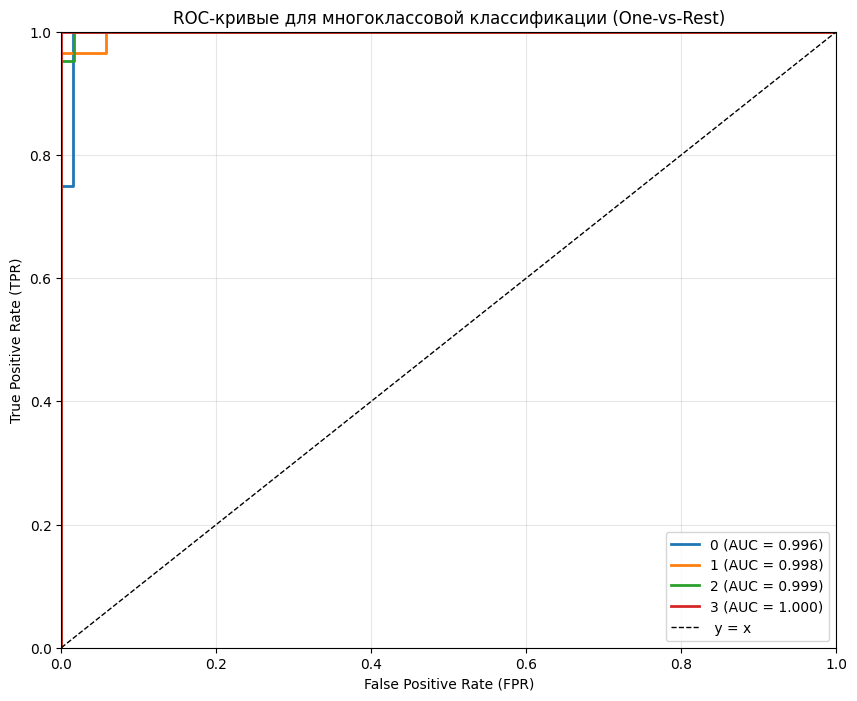

In [ ]:
y_pred_proba = lda.predict_proba(X_val)

lb = LabelBinarizer()
Y_val_bin = lb.fit_transform(Y_val)

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(lb.classes_):
    fpr, tpr, _ = roc_curve(Y_val_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label=' y = x')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривые для многоклассовой классификации (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()